<a href="https://colab.research.google.com/github/Raditya-Z/MachineLearning_244107020144/blob/main/QUIZ1/DBSCAN_MANHATTAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Setup Awal

In [1]:
import os
import time
import tracemalloc
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = 'outputDBSCANManhattan'
os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

1. Data Understanding

1.1 Load Dataset

In [2]:
df = pd.read_csv('burnout_dataset1.csv')

print(f'Jumlah data awal: {len(df)}')

# df = df.sample(
#     n=5000,
#     random_state=42
# ).reset_index(drop=True)
# print(f'Jumlah data setelah sampling: {len(df)}')

Jumlah data awal: 37637


1.2 Data Preview

In [3]:
print("5 Baris Pertama Dataset:")
display(df.head())

print("\nNama Semua Kolom:")
print(df.columns.tolist())

5 Baris Pertama Dataset:


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low



Nama Semua Kolom:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


1.3 Tipe data dan Missing Values

In [4]:
print('Tipe Data:')
print(df.dtypes)

print('\nJumlah Missing Value:')
missing = df.isnull().sum()

missing[missing > 0]

Tipe Data:
Person_ID                          int64
Age                              float64
Gender                            object
Country                           object
Occupation                        object
Education_Level                   object
Employment_Status                 object
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                       object
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                     object
Stress_Level                      object
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                object
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               float64
Gamin

,0
Age,184
Monthly_Income_USD,1111
Job_Satisfaction,370
Work_Life_Balance,486
Sleep_Hours,708
Anxiety_Score,617
Depression_Score,638
Mood_Score,642
Physical_Activity_Hours,825
Meditation_Minutes,906


1.4 Identifikasi Kolom yang Digunakan

In [5]:
# Kolom numerik asli
numeric_columns = df.select_dtypes(
    include='number'
).columns

# Kolom kategorikal
categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns

print('Kolom Numerik:')
print(
    numeric_columns.tolist()
)

print(
    '\nKolom Kategorikal yang akan di-encoding:'
)
print(
    categorical_columns
)

Kolom Numerik:
['Person_ID', 'Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Kolom Kategorikal yang akan di-encoding:
Index(['Gender', 'Country', 'Occupation', 'Education_Level',
       'Employment_Status', 'Remote_Work', 'Sleep_Quality', 'Stress_Level',
       'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet',
       'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance',
       'Support_System', 'Mental_Health_Status', 'AI_Wellness_Recommendation',
       'Burnout_Risk'],
      dtype='object')


1.5 Statistik Deskriptif

In [6]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Person_ID,37637.0,18819.000000,10865.010377,1.0,9410.0,18819.0,28228.00,37637.0
Age,37453.0,41.440312,13.837426,18.0,29.0,41.0,53.00,65.0
Monthly_Income_USD,36526.0,6241.815228,3325.947153,500.0,3359.0,6220.0,9141.75,12000.0
Work_Hours_Per_Week,37637.0,44.968542,14.737643,20.0,32.0,45.0,58.00,70.0
Job_Satisfaction,37267.0,5.501489,2.867757,1.0,3.0,6.0,8.00,10.0
Work_Life_Balance,37151.0,5.514656,2.867077,1.0,3.0,6.0,8.00,10.0
Sleep_Hours,36929.0,6.993501,1.726958,4.0,5.5,7.0,8.50,10.0
Anxiety_Score,37020.0,40.469854,26.029602,0.0,19.0,39.0,59.00,100.0
Depression_Score,36999.0,40.660775,26.337300,0.0,19.0,39.0,60.00,100.0
Mood_Score,36995.0,59.580295,25.777777,0.0,41.0,61.0,80.00,100.0


1.6 Visualisasi Distribusi Data

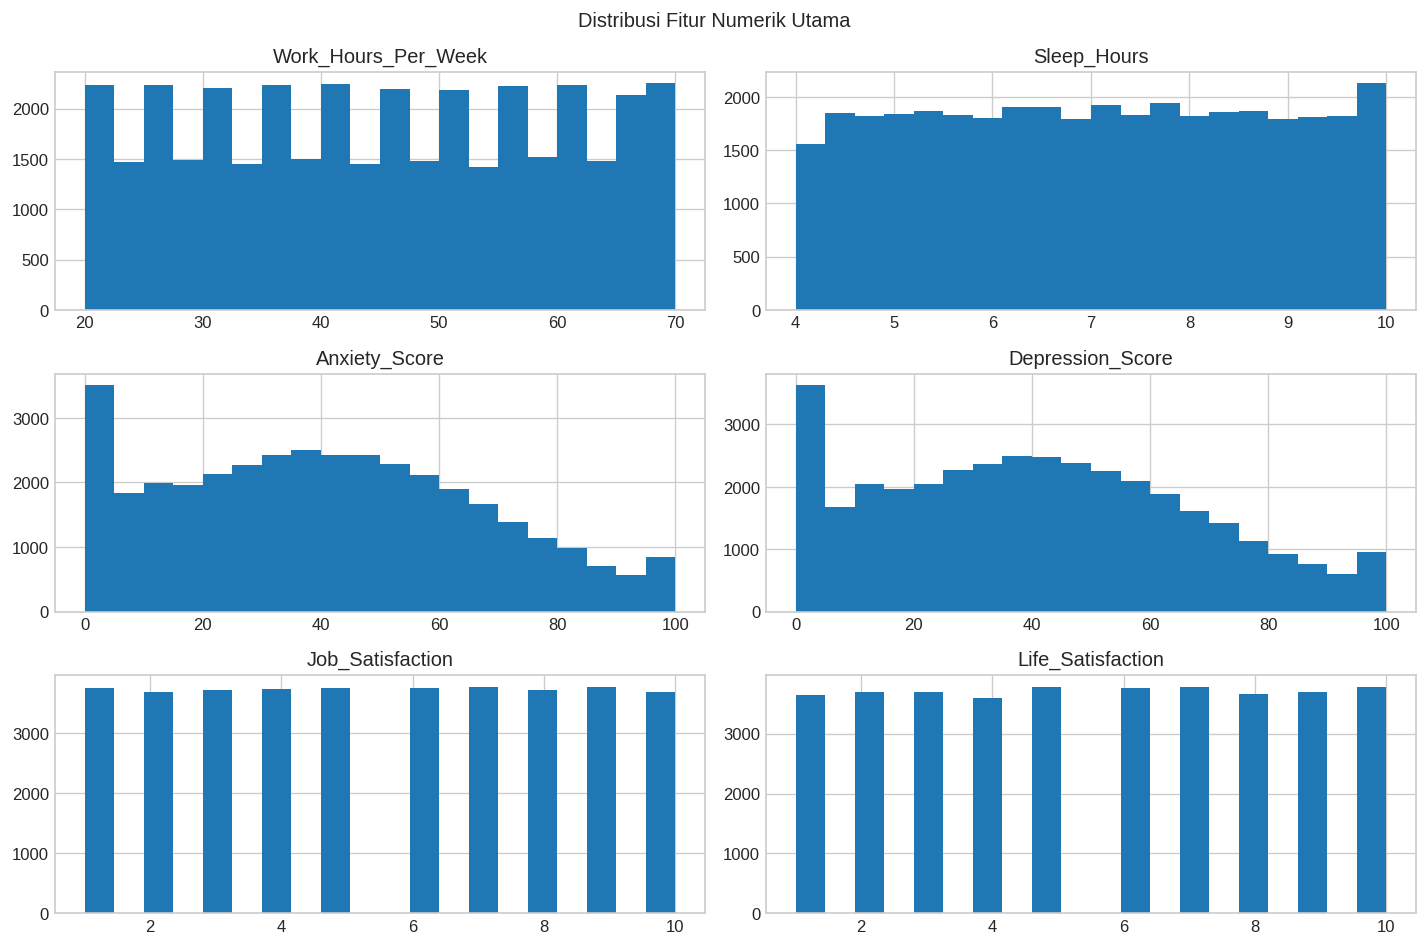

In [7]:
selected_features = [
    'Work_Hours_Per_Week',
    'Sleep_Hours',
    'Anxiety_Score',
    'Depression_Score',
    'Job_Satisfaction',
    'Life_Satisfaction'
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribusi Fitur Numerik Utama')
plt.tight_layout()
plt.show()

1.7 Visualisasi Deteksi Outlier

In [8]:
numeric_columns = df.select_dtypes(include='number').columns

numeric_columns = numeric_columns.drop(
    ['person_id', 'Person_ID'],
    errors='ignore'
)

numeric_data = df[numeric_columns]

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (numeric_data < lower_bound) |
    (numeric_data > upper_bound)
)

In [9]:
outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outlier_mask.sum(),
    'Persentase (%)': (
        outlier_mask.sum() / len(df) * 100
    ).round(2)
})

outlier_summary = outlier_summary.sort_values(
    'Jumlah Outlier',
    ascending=False
)

outlier_summary

,Jumlah Outlier,Persentase (%)
Age,0,0.0
Monthly_Income_USD,0,0.0
Work_Hours_Per_Week,0,0.0
Job_Satisfaction,0,0.0
Work_Life_Balance,0,0.0
Sleep_Hours,0,0.0
Anxiety_Score,0,0.0
Depression_Score,0,0.0
Mood_Score,0,0.0
Emotional_Stability,0,0.0


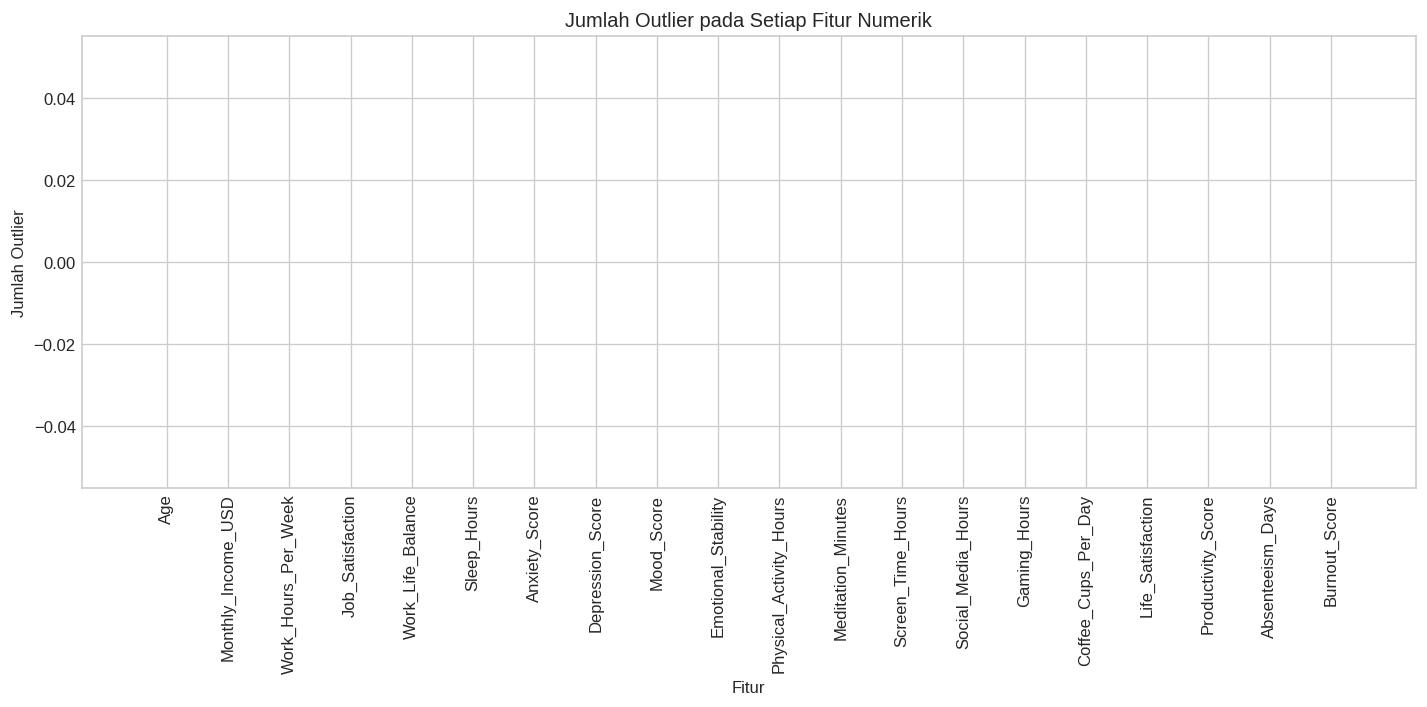

In [10]:
plt.figure(figsize=(12, 6))

plt.bar(
    outlier_summary.index,
    outlier_summary['Jumlah Outlier']
)

plt.title('Jumlah Outlier pada Setiap Fitur Numerik')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

2.1 Seleksi Kolom

In [11]:
# Drop beberapa kolom yang tidak perlu
numeric_columns = numeric_columns.drop(
    ['Burnout_Score'],
    errors='ignore'
)

categorical_columns = categorical_columns.drop(
    [
        'Gender',
        'Country',
        'Occupation',
        'AI_Wellness_Recommendation',
        'Burnout_Risk',
        'Education_Level',
        'Employment_Status'
    ],
    errors='ignore'
)

selected_columns = (
    list(numeric_columns)
    + list(categorical_columns)
)

X = df[
    selected_columns
].copy()

X.head()

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,18,...,High,Weekly,Yes,Yes,No,Yes,No,Yes,Average,Critical
1,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,37,...,Moderate,Weekly,Yes,Yes,Yes,No,Yes,No,Good,Critical
2,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,48,...,Moderate,Daily,Yes,No,No,No,Yes,No,Average,Needs Attention
3,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,80,...,Low,Weekly,Yes,No,No,No,No,Yes,Good,Healthy
4,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,76,...,Low,Never,Yes,No,No,No,Yes,No,Poor,Healthy


2.2 Encoding Data Kategorikal

In [12]:
encoding_maps = {
    'Remote_Work': {
        'No': 0,
        'Hybrid': 1,
        'Yes': 2
    },

    'Sleep_Quality': {
        'Excellent': 0,
        'Good': 1,
        'Average': 2,
        'Poor': 3
    },

    'Stress_Level': {
        'Low': 0,
        'Moderate': 1,
        'High': 2
    },

    'Exercise_Frequency': {
        'Daily': 0,
        'Weekly': 1,
        'Rarely': 2,
        'Never': 3
    },

    'Alcohol_Consumption': {
        'No': 0,
        'Yes': 1
    },

    'Smoking': {
        'No': 0,
        'Yes': 1
    },

    'Healthy_Diet': {
        'No': 1,
        'Yes': 0
    },

    'Chronic_Stress': {
        'No': 0,
        'Yes': 1
    },

    'Family_History_Mental_Illness': {
        'No': 0,
        'Yes': 1
    },

    'Therapy_Attendance': {
        'No': 1,
        'Yes': 0
    },

    'Support_System': {
        'Poor': 3,
        'Average': 2,
        'Good': 1,
        'Excellent': 0
    },

    'Mental_Health_Status': {
        'Healthy': 0,
        'Needs Attention': 1,
        'Critical': 2
    }
}

for column, mapping in encoding_maps.items():

    X[column] = (
        X[column]
        .map(mapping)
    )

X[categorical_columns].head()

,Remote_Work,Sleep_Quality,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,3,2,1,1,1,1,1,0,0.0,2,2
1,1,3,1,1,1,1,0,0,1,1.0,1,2
2,0,2,1,0,1,0,1,0,1,1.0,2,1
3,2,1,0,1,1,0,1,0,0,0.0,1,0
4,0,0,0,3,1,0,1,0,1,1.0,3,0


2.3 Penanganan Missing Values

In [13]:
print(
    'Missing value sebelum preprocessing:'
)

print(
    X.isnull().sum()
)

X = X.fillna(
    X.mean()
)

print(
    '\nJumlah missing value setelah preprocessing:'
)

print(
    X.isnull().sum()
)

Missing value sebelum preprocessing:
Age                               184
Monthly_Income_USD               1111
Work_Hours_Per_Week                 0
Job_Satisfaction                  370
Work_Life_Balance                 486
Sleep_Hours                       708
Anxiety_Score                     617
Depression_Score                  638
Mood_Score                        642
Emotional_Stability                 0
Physical_Activity_Hours           825
Meditation_Minutes                906
Screen_Time_Hours                 635
Social_Media_Hours                467
Gaming_Hours                      570
Coffee_Cups_Per_Day                 0
Life_Satisfaction                 523
Productivity_Score                701
Absenteeism_Days                    0
Remote_Work                         0
Sleep_Quality                       0
Stress_Level                        0
Exercise_Frequency                  0
Alcohol_Consumption                 0
Smoking                             0
Healthy_Diet 

2.4 Penanganan Outlier

In [14]:
# Karena tidak, tidak dilakukan

2.5 Standardisasi

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.199684,-1.054745e+00,1.494930,-0.876612,0.521454,-1.399205,1.298862,1.315036,-1.313956,-1.582734,...,1.837427,-0.458230,1.007387,1.005622,0.995784,2.530709,-0.995044,-1.013113,0.446232,1.631570
1,-1.263482,5.448541e-01,-0.065720,-0.175740,0.872520,-1.340747,0.679068,1.506513,-1.196570,-0.855223,...,0.411016,-0.458230,1.007387,1.005622,-1.004234,-0.395146,1.004981,0.994988,-0.448205,1.631570
2,1.272130,-9.354086e-01,1.019950,0.875568,0.521454,-0.405410,0.524119,0.549127,-0.609638,-0.434033,...,0.411016,-1.354753,1.007387,-0.994409,0.995784,-0.395146,1.004981,0.994988,0.446232,0.372628
3,1.706806,-6.558373e-01,-1.354953,-1.227048,1.223586,0.062258,-1.102841,-1.135873,1.112029,0.791249,...,-1.015394,-0.458230,1.007387,-0.994409,0.995784,-0.395146,-0.995044,-1.013113,-0.448205,-0.886313
4,1.634360,-2.775858e-16,0.477115,-1.577484,-0.531744,1.231428,-0.599258,0.281059,0.290324,0.638089,...,-1.015394,1.334815,1.007387,-0.994409,0.995784,-0.395146,1.004981,0.994988,1.340669,-0.886313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37632,0.982346,4.551227e-01,-1.694224,-0.526176,1.574652,-0.346952,-0.560521,-0.369964,1.072900,0.255188,...,-1.015394,-1.354753,1.007387,1.005622,-1.004234,-0.395146,-0.995044,0.994988,1.340669,-0.886313
37633,-1.263482,1.757449e+00,1.630639,-0.876612,-0.531744,-1.691498,0.330434,1.161854,-0.413994,-0.395742,...,0.411016,-0.458230,1.007387,1.005622,0.995784,-0.395146,-0.995044,0.994988,0.446232,1.631570
37634,0.040547,-7.641864e-01,0.341406,1.226004,-0.531744,0.003799,0.872754,0.012991,-0.100964,-0.778643,...,0.411016,-0.458230,-0.992667,-0.994409,0.995784,-0.395146,-0.995044,-1.013113,-1.342642,0.372628
37635,0.185439,1.908119e-01,-0.337137,0.525132,0.872520,-1.574581,1.182651,0.625718,-0.844411,-1.352994,...,0.411016,-0.458230,-0.992667,1.005622,-1.004234,-0.395146,-0.995044,0.994988,1.340669,0.372628


2.6 Data Bersih

In [16]:
print('Dimensi data setelah preprocessing:', X.shape)
print('Jumlah missing value:', X.isnull().sum().sum())

X_scaled.head()

Dimensi data setelah preprocessing: (37637, 31)
Jumlah missing value: 0


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.199684,-1.054745e+00,1.494930,-0.876612,0.521454,-1.399205,1.298862,1.315036,-1.313956,-1.582734,...,1.837427,-0.458230,1.007387,1.005622,0.995784,2.530709,-0.995044,-1.013113,0.446232,1.631570
1,-1.263482,5.448541e-01,-0.065720,-0.175740,0.872520,-1.340747,0.679068,1.506513,-1.196570,-0.855223,...,0.411016,-0.458230,1.007387,1.005622,-1.004234,-0.395146,1.004981,0.994988,-0.448205,1.631570
2,1.272130,-9.354086e-01,1.019950,0.875568,0.521454,-0.405410,0.524119,0.549127,-0.609638,-0.434033,...,0.411016,-1.354753,1.007387,-0.994409,0.995784,-0.395146,1.004981,0.994988,0.446232,0.372628
3,1.706806,-6.558373e-01,-1.354953,-1.227048,1.223586,0.062258,-1.102841,-1.135873,1.112029,0.791249,...,-1.015394,-0.458230,1.007387,-0.994409,0.995784,-0.395146,-0.995044,-1.013113,-0.448205,-0.886313
4,1.634360,-2.775858e-16,0.477115,-1.577484,-0.531744,1.231428,-0.599258,0.281059,0.290324,0.638089,...,-1.015394,1.334815,1.007387,-0.994409,0.995784,-0.395146,1.004981,0.994988,1.340669,-0.886313


3. Modeling

3.1 Penentuan Parameter DBSCAN dengan K-Distance

3.1.1 Menghitung K-Distance

In [17]:
min_samples = 10

neighbors = NearestNeighbors(
    n_neighbors=min_samples,
    metric='manhattan'
)

neighbors_fit = neighbors.fit(
    X_scaled
)

distances, indices = (
    neighbors_fit.kneighbors(
        X_scaled
    )
)

k_distances = np.sort(
    distances[:, -1]
)

print(
    'Jumlah data:',
    len(k_distances)
)

print(
    'Minimum K-Distance:',
    k_distances.min()
)

print(
    'Maximum K-Distance:',
    k_distances.max()
)

Jumlah data: 37637
Minimum K-Distance: 11.157401312171572
Maximum K-Distance: 18.815182606224937


3.1.2 Menentukan Kandidat eps

In [18]:
percentiles = [
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    75,
    80,
    85,
    90,
    92,
    94,
    96
]

eps_candidates = np.percentile(
    k_distances,
    percentiles
)

eps_candidates_df = pd.DataFrame({
    'Percentile':
        percentiles,

    'eps':
        eps_candidates
})

eps_candidates_df

,Percentile,eps
0,10,13.426148
1,20,13.815172
2,30,14.104704
3,40,14.357250
4,50,14.594822
5,60,14.830453
6,70,15.094322
7,75,15.243099
8,80,15.407339
9,85,15.606929


3.1.3 Evaluasi Kandidat eps

In [19]:
experiment_results = []

rng = np.random.RandomState(42)

for percentile, eps_candidate in zip(
    percentiles,
    eps_candidates
):

    model_test = DBSCAN(
        eps=float(
            eps_candidate
        ),
        min_samples=min_samples,
        metric='manhattan'
    )

    labels_test = model_test.fit_predict(
        X_scaled
    )

    # Hitung jumlah cluster
    n_clusters_test = (
        len(set(labels_test))
        - (
            1
            if -1 in labels_test
            else 0
        )
    )

    # Hitung noise
    n_noise_test = np.sum(
        labels_test == -1
    )

    noise_percentage_test = (
        n_noise_test
        / len(labels_test)
        * 100
    )

    # Buang noise untuk evaluasi cluster
    mask_test = (
        labels_test != -1
    )

    X_valid_test = (
        X_scaled.loc[
            mask_test
        ]
    )

    labels_valid_test = (
        labels_test[
            mask_test
        ]
    )

    unique_labels = np.unique(
        labels_valid_test
    )

    valid_cluster_count_test = len(
        unique_labels
    )

    silhouette_test = np.nan

    if (
        valid_cluster_count_test >= 2
        and len(labels_valid_test) > valid_cluster_count_test
    ):

        # Sampling terkontrol agar setiap cluster
        # tetap terwakili
        sample_indices = []

        max_sample = 5000
        total_valid = len(
            labels_valid_test
        )

        for cluster_label in unique_labels:

            cluster_indices = np.where(
                labels_valid_test
                == cluster_label
            )[0]

            cluster_size = len(
                cluster_indices
            )

            proportional_size = int(
                round(
                    max_sample
                    * cluster_size
                    / total_valid
                )
            )

            sample_size_cluster = max(
                2,
                proportional_size
            )

            sample_size_cluster = min(
                sample_size_cluster,
                cluster_size
            )

            selected_indices = rng.choice(
                cluster_indices,
                size=sample_size_cluster,
                replace=False
            )

            sample_indices.extend(
                selected_indices
            )

        sample_indices = np.array(
            sample_indices
        )

        X_sample = (
            X_valid_test.iloc[
                sample_indices
            ]
        )

        labels_sample = (
            labels_valid_test[
                sample_indices
            ]
        )

        # Pastikan sampel tetap memiliki
        # minimal 2 cluster
        if (
            len(
                np.unique(
                    labels_sample
                )
            ) >= 2
        ):

            silhouette_test = float(
                silhouette_score(
                    X_sample,
                    labels_sample,
                    metric='manhattan'
                )
            )

    experiment_results.append({
        'Percentile':
            percentile,

        'eps':
            float(
                eps_candidate
            ),

        'Jumlah Cluster':
            n_clusters_test,

        'Jumlah Noise':
            int(
                n_noise_test
            ),

        'Noise (%)':
            round(
                noise_percentage_test,
                2
            ),

        'Silhouette':
            silhouette_test
    })

eps_evaluation = pd.DataFrame(
    experiment_results
)

eps_evaluation

,Percentile,eps,Jumlah Cluster,Jumlah Noise,Noise (%),Silhouette
0,10,13.426148,108,22126,58.79,-0.262488
1,20,13.815172,45,13737,36.50,-0.236400
2,30,14.104704,14,8420,22.37,-0.134735
3,40,14.357250,6,5163,13.72,-0.071673
4,50,14.594822,2,2992,7.95,0.108819
5,60,14.830453,1,1653,4.39,NaN
6,70,15.094322,1,827,2.20,NaN
7,75,15.243099,1,559,1.49,NaN
8,80,15.407339,1,349,0.93,NaN
9,85,15.606929,1,200,0.53,NaN


3.1.4 Menentukan eps terpilih

In [20]:
valid_eps_results = eps_evaluation[
    (
        eps_evaluation[
            'Jumlah Cluster'
        ] >= 2
    )
    &
    (
        eps_evaluation[
            'Silhouette'
        ].notna()
    )
].copy()

valid_eps_results

,Percentile,eps,Jumlah Cluster,Jumlah Noise,Noise (%),Silhouette
0,10,13.426148,108,22126,58.79,-0.262488
1,20,13.815172,45,13737,36.50,-0.236400
2,30,14.104704,14,8420,22.37,-0.134735
3,40,14.357250,6,5163,13.72,-0.071673
4,50,14.594822,2,2992,7.95,0.108819


In [21]:
if len(
    valid_eps_results
) > 0:

    best_result = (
        valid_eps_results
        .sort_values(
            'Silhouette',
            ascending=False
        )
        .iloc[0]
    )

    eps = float(
        best_result[
            'eps'
        ]
    )

    print(
        'Parameter DBSCAN Manhattan terpilih'
    )

    print(
        f'eps           : '
        f'{eps:.4f}'
    )

    print(
        f'min_samples   : '
        f'{min_samples}'
    )

    print(
        f'Jumlah Cluster: '
        f'{int(best_result["Jumlah Cluster"])}'
    )

    print(
        f'Jumlah Noise  : '
        f'{int(best_result["Jumlah Noise"])}'
    )

    print(
        f'Noise (%)     : '
        f'{best_result["Noise (%)"]:.2f}%'
    )

    print(
        f'Silhouette    : '
        f'{best_result["Silhouette"]:.4f}'
    )

else:

    eps = None

    print(
        'Belum ditemukan kandidat eps '
        'yang menghasilkan minimal '
        '2 cluster valid.'
    )

    print(
        eps_evaluation.to_string(
            index=False
        )
    )

Parameter DBSCAN Manhattan terpilih
eps           : 14.5948
min_samples   : 10
Jumlah Cluster: 2
Jumlah Noise  : 2992
Noise (%)     : 7.95%
Silhouette    : 0.1088


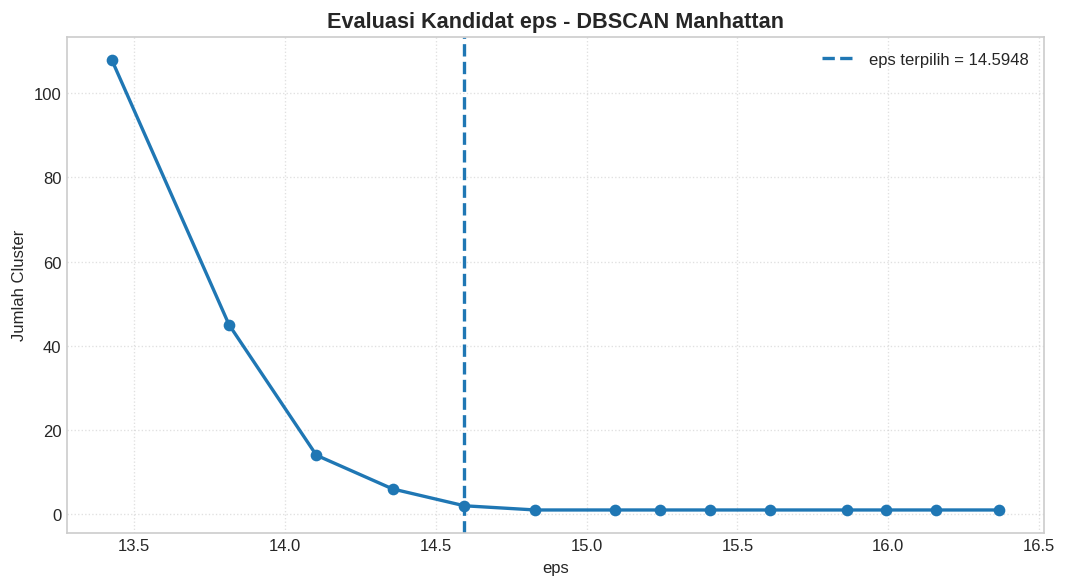

In [22]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    eps_evaluation[
        'eps'
    ],
    eps_evaluation[
        'Jumlah Cluster'
    ],
    marker='o',
    linewidth=2
)

plt.axvline(
    x=eps,
    linestyle='--',
    linewidth=2,
    label=(
        f'eps terpilih = '
        f'{eps:.4f}'
    )
)

plt.title(
    'Evaluasi Kandidat eps - '
    'DBSCAN Manhattan',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('eps')
plt.ylabel('Jumlah Cluster')

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend()

plt.tight_layout()

plt.show()

3.2 Training DBSCAN Manhattan

In [23]:
tracemalloc.start()

start_time = time.perf_counter()

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric='manhattan'
)

labels = dbscan.fit_predict(
    X_scaled
)

runtime = (
    time.perf_counter()
    - start_time
)

current_memory, peak_memory = (
    tracemalloc.get_traced_memory()
)

tracemalloc.stop()

peak_memory_mb = (
    peak_memory
    / (1024 ** 2)
)

df[
    'DBSCAN_Cluster'
] = labels

print(
    f'Runtime     : '
    f'{runtime:.5f} detik'
)

print(
    f'Peak Memory : '
    f'{peak_memory_mb:.2f} MB'
)

Runtime     : 52.33946 detik
Peak Memory : 25.89 MB


3.3 Identifikasi Cluster dan Noise

In [24]:
n_clusters = len(
    set(labels)
) - (
    1
    if -1 in labels
    else 0
)

n_noise = np.sum(
    labels == -1
)

noise_percentage = (
    n_noise
    / len(labels)
    * 100
)

n_core_points = len(
    dbscan.core_sample_indices_
)

print(
    f'Jumlah Cluster : '
    f'{n_clusters}'
)

print(
    f'Jumlah Noise   : '
    f'{n_noise}'
)

print(
    f'Persentase Noise: '
    f'{noise_percentage:.2f}%'
)

print(
    f'Core Points    : '
    f'{n_core_points}'
)

Jumlah Cluster : 2
Jumlah Noise   : 2992
Persentase Noise: 7.95%
Core Points    : 18819


4. Evaluasi

4.1 Silhouette Score

In [25]:
mask = labels != -1

X_valid = X_scaled.loc[
    mask
]

labels_valid = labels[
    mask
]

valid_cluster_count = len(
    np.unique(
        labels_valid
    )
)

if valid_cluster_count >= 2:

    silhouette = float(
        silhouette_score(
            X_valid,
            labels_valid,
            metric='manhattan'
        )
    )

else:

    silhouette = np.nan

print(
    f'Silhouette Score: '
    f'{silhouette:.4f}'
)

Silhouette Score: 0.1094


4.2 Davies-Bouldin Index

In [26]:
if valid_cluster_count >= 2:

    db_index = float(
        davies_bouldin_score(
            X_valid,
            labels_valid
        )
    )

else:

    db_index = np.nan

print(
    f'Davies-Bouldin Index: '
    f'{db_index:.4f}'
)

Davies-Bouldin Index: 0.8094


4.3 Calinski-Harabasz Index

In [27]:
if valid_cluster_count >= 2:

    ch_index = float(
        calinski_harabasz_score(
            X_valid,
            labels_valid
        )
    )

else:

    ch_index = np.nan

print(
    f'Calinski-Harabasz Index: '
    f'{ch_index:.2f}'
)

Calinski-Harabasz Index: 1.49


4.4 Distribusi Cluster

In [28]:
cluster_distribution = (
    df[
        'DBSCAN_Cluster'
    ]
    .value_counts()
    .sort_index()
)

cluster_distribution

,count
DBSCAN_Cluster,
-1,2992
0,34644
1,1


4.5 Ringkasan Evaluasi

In [29]:
model_summary = pd.DataFrame([{
    'Model':
        'DBSCAN Manhattan',

    'Distance Metric':
        'Manhattan Distance (L1)',

    'eps':
        round(
            eps,
            4
        ),

    'min_samples':
        min_samples,

    'Jumlah Cluster':
        n_clusters,

    'Jumlah Noise':
        n_noise,

    'Noise (%)':
        round(
            noise_percentage,
            2
        ),

    'Silhouette Score (↑)':
        round(
            silhouette,
            4
        ),

    'Davies-Bouldin Index (↓)':
        round(
            db_index,
            4
        ),

    'Calinski-Harabasz Index (↑)':
        round(
            ch_index,
            2
        ),

    'Execution Time (s) (↓)':
        round(
            runtime,
            5
        ),

    'Alokasi Memori (MB)':
        round(
            peak_memory_mb,
            2
        )
}])

model_summary

,Model,Distance Metric,eps,min_samples,Jumlah Cluster,Jumlah Noise,Noise (%),Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Alokasi Memori (MB)
0,DBSCAN Manhattan,Manhattan Distance (L1),14.5948,10,2,2992,7.95,0.1094,0.8094,1.49,52.33946,25.89


4.6 Export Hasil

In [30]:
excel_path = os.path.join(
    OUTPUT_DIR,
    'evaluasi_dbscan_manhattan.xlsx'
)

df_clustered = df.copy()

df_clustered[
    'DBSCAN_Cluster'
] = labels

with pd.ExcelWriter(
    excel_path,
    engine='openpyxl'
) as writer:

    model_summary.to_excel(
        writer,
        sheet_name='Ringkasan_Evaluasi',
        index=False
    )

    df_clustered.to_excel(
        writer,
        sheet_name='Data_Terklaster',
        index=False
    )

print(
    f'Hasil disimpan ke: '
    f'{excel_path}'
)

Hasil disimpan ke: outputDBSCANManhattan/evaluasi_dbscan_manhattan.xlsx


5. PCA

5.1 PCA

In [31]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

5.2 Visualisasi DBSCAN

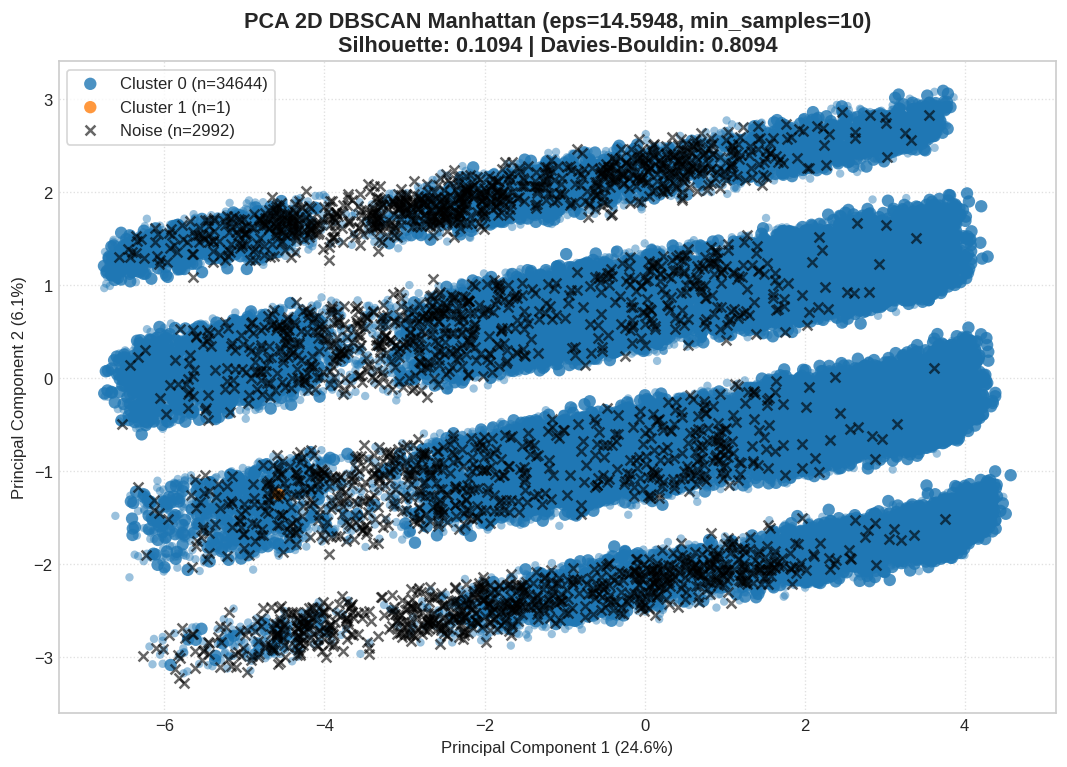

In [32]:
plt.figure(
    figsize=(9, 6.5)
)

palette = sns.color_palette(
    'tab10',
    max(
        n_clusters,
        1
    )
)

core_samples_mask = np.zeros(
    len(labels),
    dtype=bool
)

core_samples_mask[
    dbscan.core_sample_indices_
] = True

for k in range(
    n_clusters
):

    cluster_mask = (
        labels == k
    )

    core_mask = (
        cluster_mask
        & core_samples_mask
    )

    border_mask = (
        cluster_mask
        & ~core_samples_mask
    )

    # Core points
    plt.scatter(
        X_pca[
            core_mask,
            0
        ],
        X_pca[
            core_mask,
            1
        ],
        color=palette[k],
        s=55,
        alpha=0.80,
        edgecolors='none',
        label=(
            f'Cluster {k} '
            f'(n={np.sum(cluster_mask)})'
        )
    )

    # Border points
    plt.scatter(
        X_pca[
            border_mask,
            0
        ],
        X_pca[
            border_mask,
            1
        ],
        color=palette[k],
        s=25,
        alpha=0.45,
        edgecolors='none'
    )

# Noise
noise_mask = (
    labels == -1
)

plt.scatter(
    X_pca[
        noise_mask,
        0
    ],
    X_pca[
        noise_mask,
        1
    ],
    c='black',
    marker='x',
    s=35,
    alpha=0.60,
    label=(
        f'Noise '
        f'(n={np.sum(noise_mask)})'
    )
)

plt.title(
    f'PCA 2D DBSCAN Manhattan '
    f'(eps={eps:.4f}, '
    f'min_samples={min_samples})\n'
    f'Silhouette: '
    f'{silhouette:.4f} | '
    f'Davies-Bouldin: '
    f'{db_index:.4f}',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Principal Component 1 '
    f'('
    f'{pca.explained_variance_ratio_[0] * 100:.1f}%'
    f')'
)

plt.ylabel(
    'Principal Component 2 '
    f'('
    f'{pca.explained_variance_ratio_[1] * 100:.1f}%'
    f')'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend(
    frameon=True,
    loc='best'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'cluster_dbscan_manhattan.png'
    ),
    dpi=300
)

plt.show()

6. Analisis

6.1 Profil Cluster

In [33]:
df_analysis = X.copy()

df_analysis[
    'DBSCAN_Cluster'
] = labels

cluster_profile = (
    df_analysis[
        df_analysis[
            'DBSCAN_Cluster'
        ] != -1
    ]
    .groupby(
        'DBSCAN_Cluster'
    )
    .median()
)

cluster_profile

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
DBSCAN_Cluster,,,,,,,,,,,,,,,,,,,,,
0,41.0,6241.815228,44.0,5.501489,5.514656,7.0,38.0,38.0,62.0,62.0,...,1.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,26.0,11346.000000,57.0,9.000000,2.000000,7.8,79.0,73.0,21.0,24.0,...,2.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0,2.0


6.2 Perbandingan Cluster dengan Burnout Risk

In [34]:
comparison = pd.crosstab(
    df['DBSCAN_Cluster'],
    df['Burnout_Risk']
)

comparison

comparison_percentage = pd.crosstab(
    df['DBSCAN_Cluster'],
    df['Burnout_Risk'],
    normalize='index'
) * 100

comparison_percentage.round(
    2
)

Burnout_Risk,High,Low,Moderate
DBSCAN_Cluster,,,
-1,44.85,20.76,34.39
0,17.55,53.32,29.13
1,100.00,0.00,0.00


6.3 Analisis Noise

In [35]:
noise_data = df[
    df[
        'DBSCAN_Cluster'
    ] == -1
]

print(
    f'Jumlah Noise: '
    f'{len(noise_data)}'
)

print(
    f'Persentase Noise: '
    f'{len(noise_data) / len(df) * 100:.2f}%'
)

noise_data.head()

Jumlah Noise: 2992
Persentase Noise: 7.95%


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk,DBSCAN_Cluster
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low,-1
5,6,48.0,Other,Italy,Marketing Manager,PhD,Unemployed,3970.0,64,Hybrid,...,Yes,Poor,1.0,21.0,2,68,Critical,Seek Professional Support,High,-1
22,23,52.0,Male,Japan,Teacher,High School,Self-Employed,11926.0,68,Yes,...,Yes,Good,2.0,40.0,3,48,Needs Attention,Seek Professional Support,Moderate,-1
27,28,47.0,Male,Indonesia,Lawyer,Master,Self-Employed,8837.0,50,Hybrid,...,Yes,Excellent,9.0,47.0,11,77,Critical,Increase Physical Activity,High,-1
34,35,62.0,Other,Mexico,Chef,Diploma,Unemployed,11230.0,59,Yes,...,No,Poor,4.0,78.0,20,31,Healthy,Seek Professional Support,Low,-1
